## Load series from a specific ecosystem and clean the data

In [ ]:
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d
from scipy.signal import resample
import numpy as np
import os
# import functions from the utils.py in the ../scripts folder
import sys
sys.path.append('../scripts')
from utils import segment_time_series
from LaurentianMapleGrove_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names
plant_names = list(plant_common_names.keys())

# Define original and target sampling rates
original_sf = 256  # Original sampling rate
target_sf = 100  # Target sampling rate
artifacts = [19.5, 39, 29.3, 9.75]
n_minutes = 5
chunk_size = target_sf*60*n_minutes
ecosystem = 'LaurentianMapleGrove'
nan_threshold = 0.1  # Threshold for NaN values


for SEASON in seasons:
    folderpath = f'../plant_data/{SEASON}/RAW/'
    dates = filenames = [f for f in os.listdir(folderpath)]
    for date in dates:
        print(f'Processing {SEASON} {date}')
        data_all = []
        remove_idx = []
        keep_idx = []
        for plant_name in plant_names:
            filename = f'{plant_name} {date}.raw'
            try:
                data = np.fromfile(folderpath + date + '/' + filename)
            except:
                print(f'{plant_name} not found')
                remove_idx.append(plant_names.index(plant_name))
                continue

            # Check proportion of NaN values
            nan_proportion = np.sum(np.isnan(data)) / len(data)
            #print(f'{plant_name} has {nan_proportion:.2f} NaN values')
            if nan_proportion > nan_threshold:
                print(f'{plant_name} has too many NaN values', 'proportion:', nan_proportion)
                remove_idx.append(plant_names.index(plant_name))
            else:
                keep_idx.append(plant_names.index(plant_name))
                # Interpolate NaN values
                nan_mask = np.isnan(data)
                if np.any(nan_mask):  # Only interpolate if there are NaNs
                    x = np.arange(len(data))  # Indices
                    y = data.copy()
                    y[nan_mask] = np.interp(x[nan_mask], x[~nan_mask], y[~nan_mask])  # Linear interpolation
                    data = y  # Replace original data with interpolated version
        
                # normalize between 0 and 1
                data = (data - np.min(data)) / (np.max(data) - np.min(data))
                # Compute new length for resampling
                new_length = int(len(data) * target_sf / original_sf)
                
                # remove artifacts with a notch filter
                for f in artifacts:
                    b, a = butter(2, [f - 0.1, f + 0.1], btype='bandstop', fs=target_sf)
                    data = filtfilt(b, a, data)
                # Resample the data
                data = resample(data, new_length)
                data_all.append(data)

        new_data_all = []
        if data_all == []:
            print(f'No data for {SEASON} {date}')
            continue
        for ts in data_all:
            # Segment the time series into chunks of 5 minutes
            bounds_time = np.arange(0, len(ts), chunk_size)
            segments = segment_time_series(ts, bounds_time)
            segments = segments[1:-1]
            new_data_all.append(list(segments))
        new_data_all = np.array(new_data_all)
        new_data_all = np.swapaxes(new_data_all, 0, 1)

        data_ = new_data_all  # Your main numerical array
        kept_plants = [plant_names[i] for i in keep_idx]
        kept_plants = np.array(kept_plants, dtype=object)
        keep_idx = np.array(keep_idx)  # Convert index list to numpy array
        # Save all in a single file
        #create a folder to save the data
        if not os.path.exists(f'../plant_data_{ecosystem}/{seasons[SEASON]}/{date}'):
            os.makedirs(f'../plant_data_{ecosystem}/{seasons[SEASON]}/{date}')
        np.savez(f'../plant_data_{ecosystem}/{seasons[SEASON]}/{date}/plant_data.npz', data=data_, plant_names=kept_plants, keep_idx=keep_idx, date=date, season_name=seasons[SEASON], serie=SEASON)

Processing Serie 3 2024-04-30
Geum rivale has too many NaN values proportion: 0.9703447472638288
Myrica gale has too many NaN values proportion: 0.8715270003736363
Processing Serie 3 2024-05-01
Polystichum acrostichoides has too many NaN values proportion: 0.14442729683542066
Geum rivale has too many NaN values proportion: 0.9997991659009923
Myrica gale has too many NaN values proportion: 0.9884186272406091
Processing Serie 3 2024-05-02
Polystichum acrostichoides has too many NaN values proportion: 0.18775713494365887
Geum rivale has too many NaN values proportion: 0.17171030489338795
Myrica gale has too many NaN values proportion: 0.9975496618916813
Processing Serie 3 2024-05-03
Acer rubrum not found
Rhododendron groenlandicum not found
Dryopteris mas not found
Polystichum acrostichoides not found
Alnus not found
Geum rivale not found
Myrica gale not found
Acer pensylvanicum not found
No data for Serie 3 2024-05-03
Processing Serie 3 2024-05-04
Polystichum acrostichoides has too many 

## Plot raw data

C:\Users\skite\AppData\Local\Temp\ipykernel_54840\1176772085.py:6: RuntimeWarning: invalid value encountered in subtract
  data = (data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data))
C:\Users\skite\AppData\Local\Temp\ipykernel_54840\1176772085.py:6: RuntimeWarning: All-NaN slice encountered
  data = (data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data))


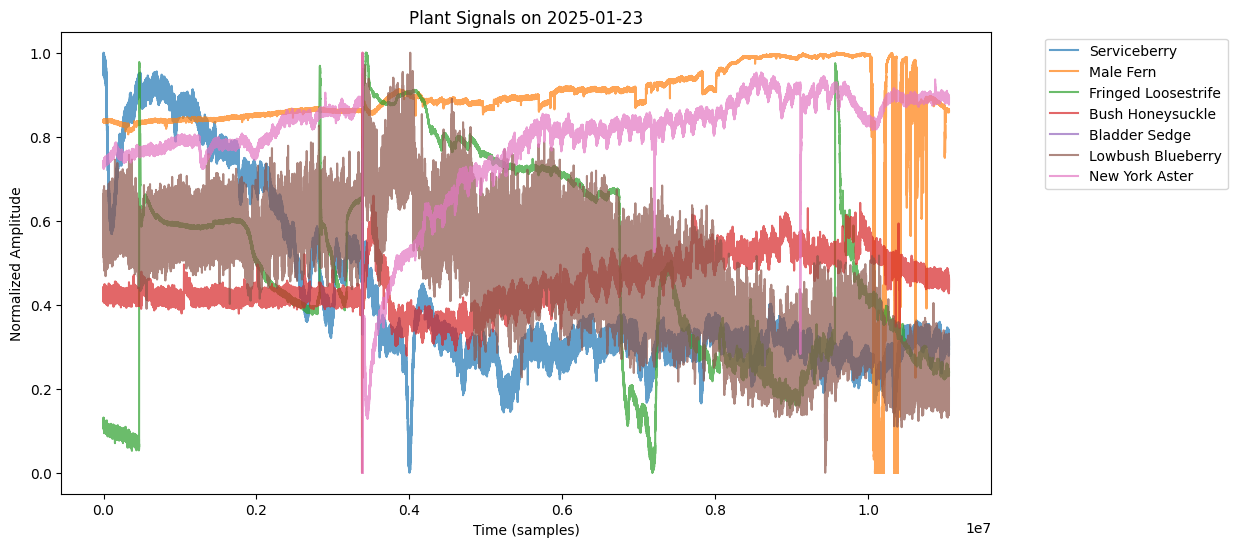

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))

for plant_name in plant_names:
    filename = f'{plant_name} {dates[0]}.raw'
    data = np.fromfile(folderpath + dates[0] + '/' + filename)
    data = (data - np.nanmin(data)) / (np.nanmax(data) - np.nanmin(data))
    plt.plot(data, label=plant_common_names[plant_name], alpha=0.7)

plt.title(f'Plant Signals on {dates[0]}')
plt.xlabel('Time (samples)')
plt.ylabel('Normalized Amplitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

## Check proportion of nans

In [170]:
import pandas as pd
# Initialize empty DataFrame with plants as index and dates as columns
df_nan = pd.DataFrame(index=plant_names, columns=dates)

# Fill the DataFrame with NaN proportions
for date in dates:
    datapath = f'{folderpath}{date}'
    for plant_name in plant_names:
        try:
            filename = f'{plant_name} {date}.raw'
            data = np.fromfile(datapath + '/' + filename)
            nan_proportion = np.sum(np.isnan(data))/len(data)
            df_nan.loc[plant_name, date] = nan_proportion
        except:
            df_nan.loc[plant_name, date ] = np.nan

# Format the values to show only 2 decimal places
df_nan = df_nan.round(2)
df_nan

,2025-01-23,2025-01-24,2025-01-25,2025-01-26,2025-01-27,2025-01-28,2025-01-29,2025-01-30,2025-01-31,2025-02-01,2025-02-02
Amelanchier canadensis,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Dryopteris filix-mas,0.004461,0.00448,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Lysimachia ciliata,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Onoclea sensibilis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Diervilla lonicera,0.0,0.0,0.0,0.0,0.005327,0.03866,0.0512,0.014858,0.001843,0.035216,0.090027
Carex intumescens,1.0,1.0,0.998372,0.999996,0.978235,0.790166,0.411157,0.764123,0.242009,0.019107,0.53274
Vaccinium angustifolium,0.0,0.22895,0.877195,0.999889,0.969757,0.999997,0.999804,0.999704,0.999915,0.999603,0.901526
Symphiotrum novi-belgii,0.000186,0.0,0.0,0.0,0.00011,0.0,0.000281,0.0,0.000157,0.0,0.000296
